**IMPORTS**

In [31]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from keras import Sequential, Input, layers, optimizers
from keras.callbacks import EarlyStopping, ModelCheckpoint
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50
from keras.applications.efficientnet import EfficientNetB0
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd
import seaborn as sns
from PIL import Image

**CONFIGURATION**

In [5]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
RANDOM_SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

**PATHS**

In [6]:
ORIGINAL_DIR = "../raw_data/Original"
AUGMENTED_DIR = "../raw_data/Augmented"

**LOAD DATASETS FROM DIRECTORY**

In [7]:
## Train dataset - Augmented data

train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    AUGMENTED_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["Non-Stone", "Stone"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=RANDOM_SEED
)

Found 35457 files belonging to 2 classes.


2026-03-07 11:59:57.948631: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2026-03-07 11:59:57.948701: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-03-07 11:59:57.948708: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-03-07 11:59:57.948779: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-07 11:59:57.948799: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
## Full Original Dataset

full_original = tf.keras.preprocessing.image_dataset_from_directory(
    ORIGINAL_DIR,
    labels="inferred",
    label_mode="binary",
    class_names=["Non-Stone", "Stone"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=RANDOM_SEED
)

Found 3364 files belonging to 2 classes.


In [9]:
full_original_shuffled = full_original.shuffle(
    buffer_size=len(full_original) * BATCH_SIZE,
    seed=RANDOM_SEED,
    reshuffle_each_iteration=False
)

**SPLIT ORIGINAL DATASET**

In [10]:
## Val and Test dataset - From Full Original dataset

total_batches = len(full_original)
val_batches = total_batches // 2

val_dataset = full_original_shuffled.take(val_batches).cache().prefetch(AUTOTUNE)
test_dataset = full_original_shuffled.skip(val_batches).cache().prefetch(AUTOTUNE)

print(train_dataset.class_names)
print(len(train_dataset))
print(len(val_dataset))
print(len(test_dataset))

['Non-Stone', 'Stone']
1109
53
53


In [11]:
true_val_labels = np.concatenate([y.numpy() for _, y in val_dataset]).flatten().astype(int)
print(f"Val unique labels : {np.unique(true_val_labels)}")
print(f"Val label counts  : {np.bincount(true_val_labels)}")

Val unique labels : [0 1]
Val label counts  : [891 805]


2026-03-07 12:00:15.529101: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## BASELINE MODEL CNN

In [65]:
def build_baseline_model():
    model = Sequential()

    model.add(Input((224, 224, 3)))

    model.add(layers.Rescaling(1./255))

    model.add(layers.Conv2D(16, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Conv2D(32, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Conv2D(64, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Conv2D(128, kernel_size=3, padding='same', activation='relu'))
    model.add(layers.MaxPooling2D(2))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(1, activation='sigmoid'))

    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizers.Adam(learning_rate=1e-4),
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )

    return model

In [78]:
baseline_model = build_baseline_model()
baseline_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_3 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 224, 224, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,520,481 (24.87 MB)

 Trainable params: 6,520,481 (24.87 MB)

 Non-trainable params: 0 (0.00 B)

In [79]:
# CALLBACKS

es = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=10,
    verbose=1,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    filepath="../models/baseline_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [80]:
# TRAIN

history = baseline_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=30,
    callbacks=[es, checkpoint]
)

Epoch 1/30
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.6545 - auc: 0.7035 - loss: 0.6828 - precision: 0.6459 - recall: 0.5243
Epoch 1: val_auc improved from None to 0.96390, saving model to ../models/baseline_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 40s 35ms/step - accuracy: 0.7131 - auc: 0.7742 - loss: 0.9583 - precision: 0.7029 - recall: 0.6457 - val_accuracy: 0.9163 - val_auc: 0.9639 - val_loss: 0.3479 - val_precision: 0.9159 - val_recall: 0.9068
Epoch 2/30
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7509 - auc: 0.7731 - loss: 12.9487 - precision: 0.7282 - recall: 0.7269
Epoch 2: val_auc did not improve from 0.96390
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 38s 34ms/step - accuracy: 0.7502 - auc: 0.7601 - loss: 49.2092 - precision: 0.7273 - recall: 0.7260 - val_accuracy: 0.9139 - val_auc: 0.9115 - val_loss: 51.6070 - val_precision: 0.9596 - val_recall: 0.8547
Epoch 3/30
1107/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.7475 - auc: 0.7457 - loss: 632.9506 - 

In [81]:
results = baseline_model.evaluate(test_dataset, verbose=1, return_dict=True)
print(results)

53/53 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.9329 - auc: 0.9534 - loss: 0.4523 - precision: 0.9472 - recall: 0.9054
{'accuracy': 0.9328536987304688, 'auc': 0.953393816947937, 'loss': 0.4523378312587738, 'precision': 0.9471544623374939, 'recall': 0.9054403901100159}


In [12]:
def plot_history(history, title):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    # Accuracy
    axes[0].plot(history.history['accuracy'],     label='Train')
    axes[0].plot(history.history['val_accuracy'], label='Val')
    axes[0].set_title(f'{title} — Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].legend()

    # Loss
    axes[1].plot(history.history['loss'],     label='Train')
    axes[1].plot(history.history['val_loss'], label='Val')
    axes[1].set_title(f'{title} — Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].legend()

    # AUC
    axes[2].plot(history.history['auc'],     label='Train')
    axes[2].plot(history.history['val_auc'], label='Val')
    axes[2].set_title(f'{title} — AUC')
    axes[2].set_xlabel('Epoch')
    axes[2].legend()

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

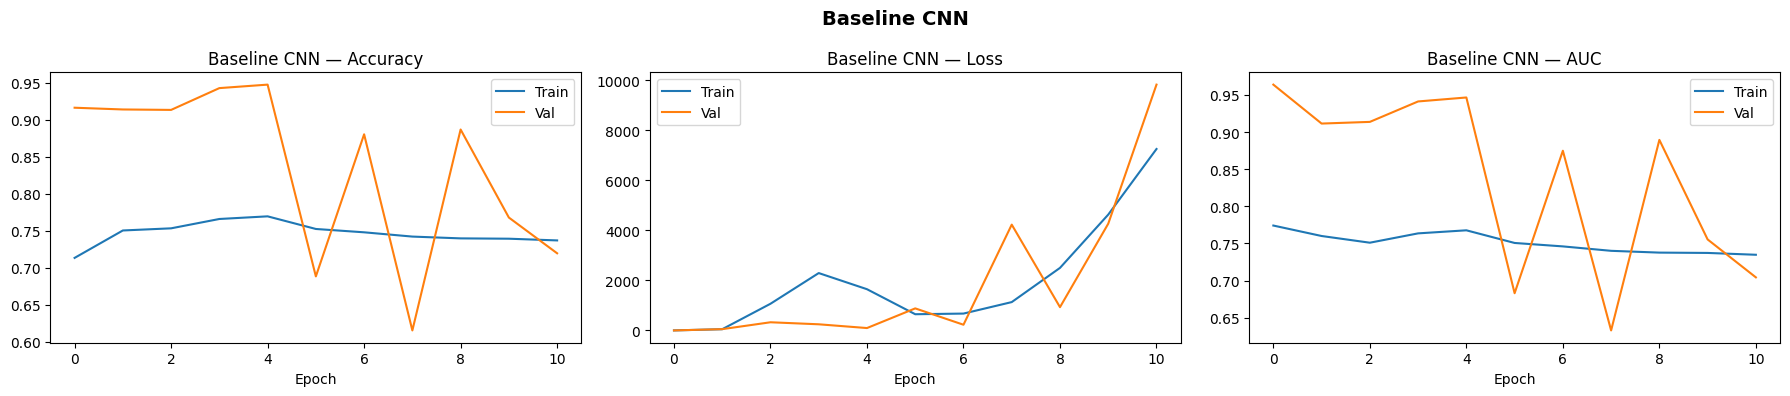

In [82]:
plot_history(history, "Baseline CNN")

**Classification report**

In [13]:
target_names = ["Non-stone", "Stone"]
true_labels = np.concatenate([y.numpy() for _, y in test_dataset]).flatten().astype(int)

2026-03-07 12:00:42.263095: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
def get_classification_report(model, test_dt):
    pred_probs = model.predict(test_dt, verbose=1)
    pred_labels = (pred_probs > 0.5).astype(int).flatten()
    report = classification_report(true_labels, pred_labels, target_names=target_names)

    return report, pred_labels

In [142]:
baseline_report, baseline_pred_labels = get_classification_report(baseline_model, test_dataset)
print(baseline_report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step
              precision    recall  f1-score   support

   Non-stone       0.92      0.96      0.94       896
       Stone       0.95      0.91      0.93       772

    accuracy                           0.93      1668
   macro avg       0.93      0.93      0.93      1668
weighted avg       0.93      0.93      0.93      1668



In [ ]:
def plot_cm(pred_labels, title):
    cm = confusion_matrix(true_labels, pred_labels)
    cm = pd.DataFrame(cm,
                    index=["True Non-Stone", "True Stone"],
                    columns=["Pred Non-Stone", "Pred Stone"])

    plt.figure(figsize=(7,5))

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", annot_kws={"size": 14})
    plt.title(f"Confusion Matrix - {title}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show

    return cm

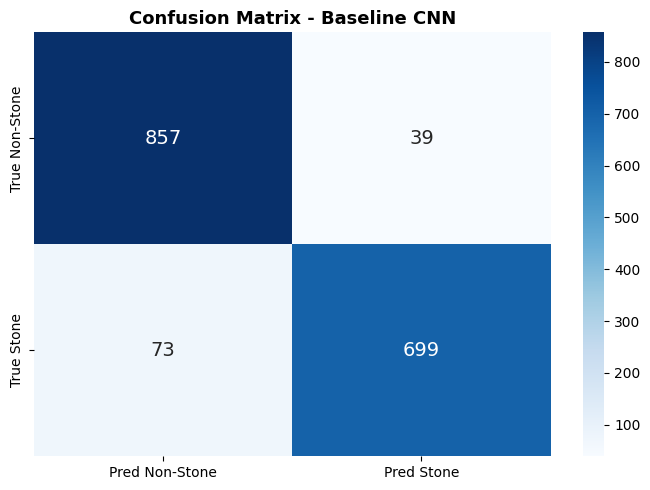

In [165]:
cm_baseline_model = plot_cm(baseline_pred_labels, "Baseline CNN")

**PREPROCESSING LAYERS**

In [16]:
vgg_preprocess = tf.keras.applications.vgg16.preprocess_input
resnet_preprocess = tf.keras.applications.resnet50.preprocess_input
efficientnet_preprocess = tf.keras.applications.efficientnet.preprocess_input

In [17]:
def prepare(dataset, preprocess_input):
    return (
        dataset.map(lambda img, label: (preprocess_input(img), label), num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
    )

In [18]:
def get_datasets(preprocess_input):
    return (
        prepare(train_dataset, preprocess_input),
        prepare(val_dataset, preprocess_input),
        prepare(test_dataset, preprocess_input)
    )

## VGG16

In [ ]:
train_vgg, val_vgg, test_vgg = get_datasets(vgg_preprocess)

In [ ]:
input_shape = IMG_SIZE + (3,)

def load_model(pretrained_model):

    model = pretrained_model(weights="imagenet", include_top=False, input_shape=input_shape)

    return model

In [20]:
def set_nontrainable_layers(model):
    model.trainable = False
    return model

In [21]:
def add_last_layers(model):
    '''Take a pre-trained model, set its parameters as non-trainable, and add additional trainable layers on top'''
    # $CHALLENGIFY_BEGIN
    base_model = set_nontrainable_layers(model)
    pooling_layer = layers.GlobalAveragePooling2D()
    dense_layer = layers.Dense(256, activation='relu')
    prediction_layer = layers.Dense(1, activation='sigmoid')


    model = Sequential([
        base_model,
        pooling_layer,
        dense_layer,
        prediction_layer
    ])
    return model

In [22]:
def build_pretrained_model(pretrained_model):
    model = load_model(pretrained_model)
    model = add_last_layers(model)

    model.compile(
        loss="binary_crossentropy",
        optimizer=optimizers.Adam(learning_rate=1e-4),
        metrics=["accuracy",
                 keras.metrics.AUC(name="auc"),
                 keras.metrics.Precision(name="precision"),
                 keras.metrics.Recall(name="recall")]
    )
    return model

In [118]:
vgg_model = build_pretrained_model(VGG16)
vgg_model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,846,273 (56.63 MB)

 Trainable params: 131,585 (514.00 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [119]:
# CALLBACKS

es_vgg = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=5,
    verbose=1,
    restore_best_weights=True
)

checkpoint_vgg = ModelCheckpoint(
    filepath="../models/vgg_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [120]:
vgg_history = vgg_model.fit(train_vgg,
                            validation_data=val_vgg,
                            epochs=20,
                            callbacks=[es_vgg, checkpoint_vgg])

Epoch 1/20
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 154ms/step - accuracy: 0.6808 - auc: 0.7242 - loss: 0.7510 - precision: 0.6605 - recall: 0.6331
Epoch 1: val_auc improved from None to 0.94347, saving model to ../models/vgg_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 180s 162ms/step - accuracy: 0.7571 - auc: 0.8246 - loss: 0.5352 - precision: 0.7481 - recall: 0.7071 - val_accuracy: 0.8673 - val_auc: 0.9435 - val_loss: 0.3203 - val_precision: 0.9328 - val_recall: 0.7764
Epoch 2/20
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step - accuracy: 0.8203 - auc: 0.8968 - loss: 0.4020 - precision: 0.8254 - recall: 0.7709
Epoch 2: val_auc improved from 0.94347 to 0.95435, saving model to ../models/vgg_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 185s 167ms/step - accuracy: 0.8317 - auc: 0.9061 - loss: 0.3832 - precision: 0.8336 - recall: 0.7896 - val_accuracy: 0.8821 - val_auc: 0.9543 - val_loss: 0.2760 - val_precision: 0.9150 - val_recall: 0.8286
Epoch 3/20
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accur

In [145]:
vgg_results = vgg_model.evaluate(test_vgg, verbose=1, return_dict=True)
print(vgg_results)

53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 149ms/step - accuracy: 0.9089 - auc: 0.9746 - loss: 0.2248 - precision: 0.9641 - recall: 0.8342
{'accuracy': 0.9088729023933411, 'auc': 0.9745681881904602, 'loss': 0.22476749122142792, 'precision': 0.9640718698501587, 'recall': 0.8341968655586243}


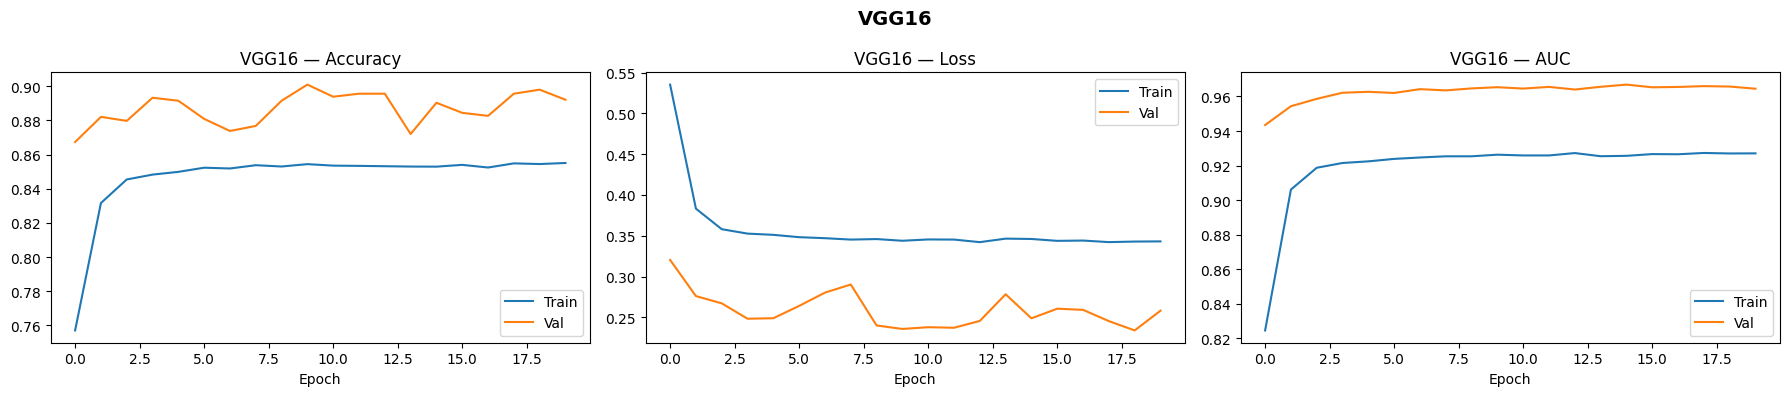

In [146]:
plot_history(vgg_history, "VGG16")

In [147]:
vgg_report, vgg_pred_labels = get_classification_report(vgg_model, test_vgg)
print(vgg_report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 8s 147ms/step
              precision    recall  f1-score   support

   Non-stone       0.87      0.97      0.92       896
       Stone       0.96      0.83      0.89       772

    accuracy                           0.91      1668
   macro avg       0.92      0.90      0.91      1668
weighted avg       0.91      0.91      0.91      1668



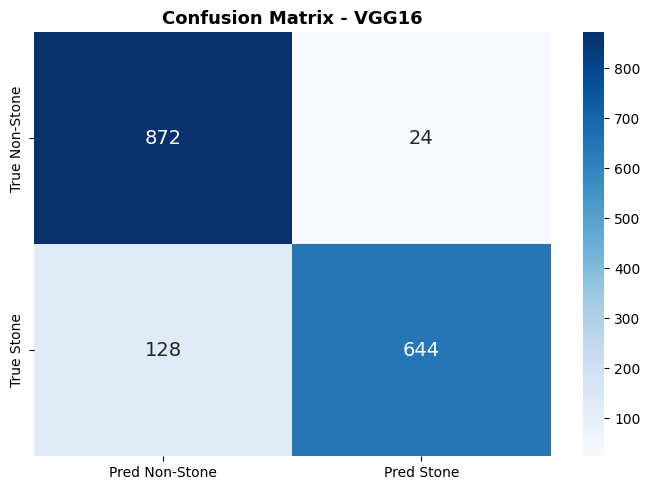

In [166]:
cm_vgg = plot_cm(vgg_pred_labels, "VGG16")

## ResNet50

In [128]:
train_resnet, val_resnet, test_resnet = get_datasets(resnet_preprocess)

In [129]:
resnet_model = build_pretrained_model(ResNet50)
resnet_model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,112,513 (91.98 MB)

 Trainable params: 524,801 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [130]:
# CALLBACKS

es_resnet = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=8,
    verbose=1,
    restore_best_weights=True
)

checkpoint_resnet = ModelCheckpoint(
    filepath="../models/resnet_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [131]:
resnet_history = resnet_model.fit(train_resnet,
                            validation_data=val_resnet,
                            epochs=30,
                            callbacks=[es_resnet, checkpoint_resnet])

Epoch 1/30
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.7389 - auc: 0.8044 - loss: 0.5240 - precision: 0.7341 - recall: 0.6743
Epoch 1: val_auc improved from None to 0.96533, saving model to ../models/resnet_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 128s 111ms/step - accuracy: 0.7981 - auc: 0.8740 - loss: 0.4411 - precision: 0.8024 - recall: 0.7411 - val_accuracy: 0.9068 - val_auc: 0.9653 - val_loss: 0.2614 - val_precision: 0.9308 - val_recall: 0.8683
Epoch 2/30
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.8562 - auc: 0.9267 - loss: 0.3433 - precision: 0.8626 - recall: 0.8160
Epoch 2: val_auc improved from 0.96533 to 0.97994, saving model to ../models/resnet_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 120s 108ms/step - accuracy: 0.8689 - auc: 0.9367 - loss: 0.3215 - precision: 0.8769 - recall: 0.8299 - val_accuracy: 0.9304 - val_auc: 0.9799 - val_loss: 0.2011 - val_precision: 0.9598 - val_recall: 0.8907
Epoch 3/30
1108/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step -

In [149]:
resnet_results = resnet_model.evaluate(test_resnet, verbose=1, return_dict=True)
print(resnet_results)

53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 99ms/step - accuracy: 0.9466 - auc: 0.9936 - loss: 0.1324 - precision: 0.9100 - recall: 0.9819
{'accuracy': 0.9466426968574524, 'auc': 0.9935991764068604, 'loss': 0.1323748677968979, 'precision': 0.9099639654159546, 'recall': 0.9818652868270874}


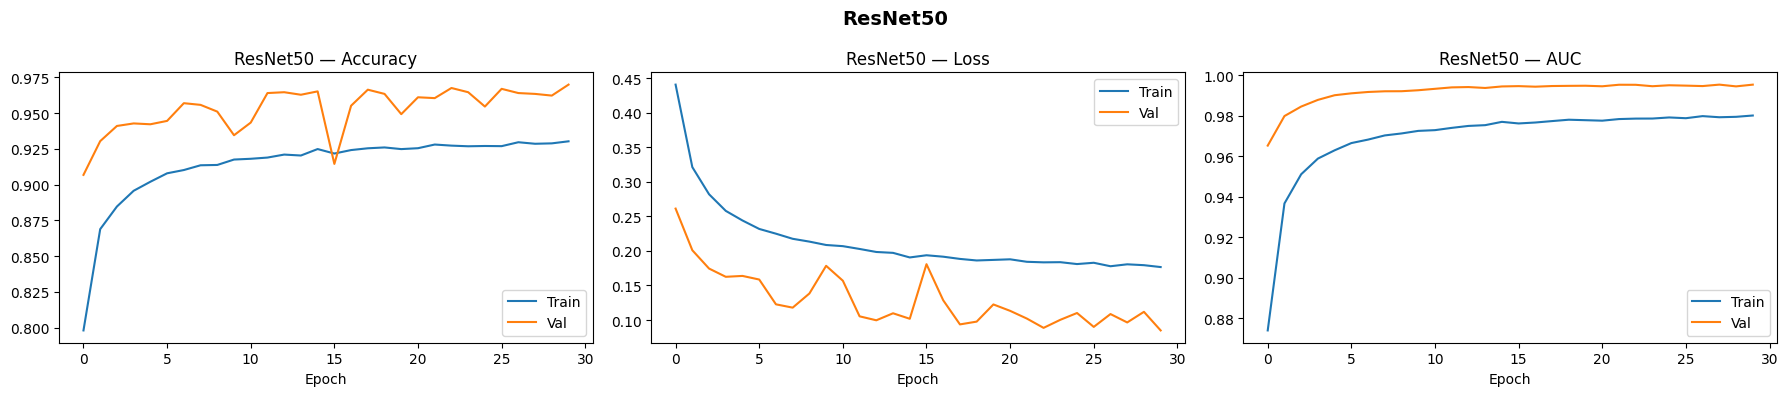

In [150]:
plot_history(resnet_history, "ResNet50")

In [151]:
resnet_report, resnet_pred_labels = get_classification_report(resnet_model, test_resnet)
print(resnet_report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step
              precision    recall  f1-score   support

   Non-stone       0.98      0.92      0.95       896
       Stone       0.91      0.98      0.94       772

    accuracy                           0.95      1668
   macro avg       0.95      0.95      0.95      1668
weighted avg       0.95      0.95      0.95      1668



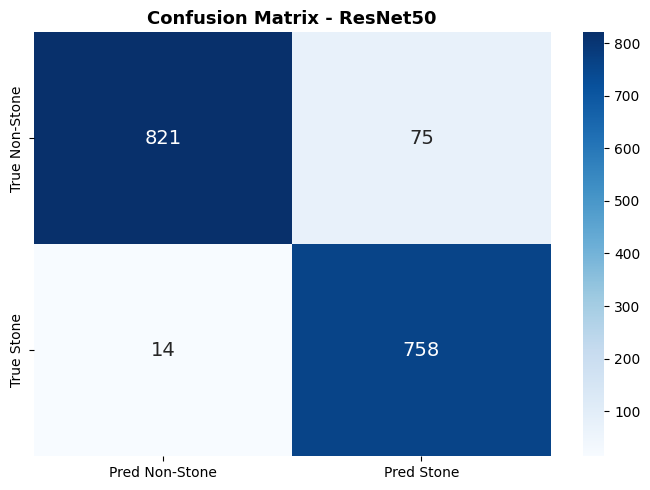

In [167]:
cm_resnet = plot_cm(resnet_pred_labels, "ResNet50")

## EfficientNet

In [27]:
train_efficientnet, val_efficientnet, test_efficientnet = get_datasets(efficientnet_preprocess)

In [154]:
efficientnet_model = build_pretrained_model(EfficientNetB0)
efficientnet_model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,377,764 (16.70 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [155]:
# CALLBACKS

es_efficientnet = EarlyStopping(
    monitor="val_auc",
    mode="max",
    patience=7,
    verbose=1,
    restore_best_weights=True
)

checkpoint_efficientnet = ModelCheckpoint(
    filepath="../models/efficientnet_best.keras",
    monitor="val_auc",
    mode="max",
    save_best_only=True,
    verbose=1
)

In [156]:
efficientnet_history = efficientnet_model.fit(train_efficientnet,
                            validation_data=val_efficientnet,
                            epochs=25,
                            callbacks=[es_efficientnet, checkpoint_efficientnet])

Epoch 1/25
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.7188 - auc: 0.7875 - loss: 0.5474 - precision: 0.7184 - recall: 0.6320
Epoch 1: val_auc improved from None to 0.94784, saving model to ../models/efficientnet_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 107s 87ms/step - accuracy: 0.7727 - auc: 0.8495 - loss: 0.4844 - precision: 0.7811 - recall: 0.6988 - val_accuracy: 0.8597 - val_auc: 0.9478 - val_loss: 0.3299 - val_precision: 0.9175 - val_recall: 0.7739
Epoch 2/25
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8339 - auc: 0.9080 - loss: 0.3907 - precision: 0.8451 - recall: 0.7800
Epoch 2: val_auc improved from 0.94784 to 0.96732, saving model to ../models/efficientnet_best.keras
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 90s 81ms/step - accuracy: 0.8428 - auc: 0.9162 - loss: 0.3738 - precision: 0.8528 - recall: 0.7931 - val_accuracy: 0.8962 - val_auc: 0.9673 - val_loss: 0.2566 - val_precision: 0.9037 - val_recall: 0.8745
Epoch 3/25
1109/1109 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/

In [36]:
efficientnet_results = efficientnet_model.evaluate(test_efficientnet, verbose=1, return_dict=True)
print(efficientnet_results)

53/53 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9526 - auc: 0.9911 - loss: 0.1497 - precision: 0.9304 - recall: 0.9702
{'accuracy': 0.9526379108428955, 'auc': 0.9910902380943298, 'loss': 0.1496768444776535, 'precision': 0.9304347634315491, 'recall': 0.9702072739601135}


In [ ]:
plot_history(efficientnet_history, "EfficientNetB0")

NameError: name 'efficientnet_history' is not defined

In [38]:
efficientnet_report, efficientnet_pred_labels = get_classification_report(efficientnet_model, test_efficientnet)
print(efficientnet_report)

53/53 ━━━━━━━━━━━━━━━━━━━━ 9s 124ms/step
              precision    recall  f1-score   support

   Non-stone       0.97      0.94      0.96       896
       Stone       0.93      0.97      0.95       772

    accuracy                           0.95      1668
   macro avg       0.95      0.95      0.95      1668
weighted avg       0.95      0.95      0.95      1668



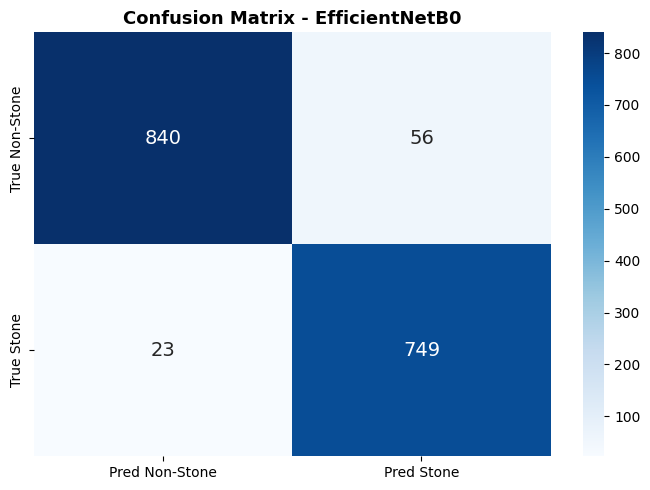

In [39]:
cm_efficientnet = plot_cm(efficientnet_pred_labels, "EfficientNetB0")

In [28]:
def predict_with_confidence(model, img_tensor):
    prob = model.predict(img_tensor, verbose=0)  # raw sigmoid output e.g. 0.923
    prob = float(prob.flatten()[0])              # scalar

    if prob >= 0.5:
        label = "Stone"
        confidence = prob                        # e.g. 0.923 → 92.3% confident it's a Stone
    else:
        label = "Non-Stone"
        confidence = 1 - prob                   # e.g. 0.12 → 88% confident it's Non-Stone

    return label, round(confidence * 100, 2)    # returns ("Stone", 92.3)

In [29]:
# Example usage on a single image from test_dataset
for images, labels in test_efficientnet.take(1):
    img = images[0:1]                           # take first image, keep batch dimension
    true_label = int(labels[0].numpy())

    label, confidence = predict_with_confidence(efficientnet_model, img)

    label_names = {0: "Non-Stone", 1: "Stone"}
    print(f"True label  : {label_names[true_label]}")
    print(f"Prediction  : {label}")
    print(f"Confidence  : {confidence}%")

/var/folders/lw/rvgrg7c94tg8r69r3wm5l1cw0000gn/T/ipykernel_31612/2185748468.py:4: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(labels[0].numpy())
2026-03-07 12:04:18.636456: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


True label  : Stone
Prediction  : Stone
Confidence  : 99.89%


2026-03-07 12:04:20.748391: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [ ]:
import torch

print(torch.__version__)
print(f"MPS available: {torch.backends.mps.is_available()}")

2.10.0
MPS available: True


In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

device = "mps" if torch.backends.mps.is_available() else "cpu"

model_name = "microsoft/Phi-3.5-mini-instruct"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,  # float16 saves memory on MPS
    device_map=device
)

/Users/acisneros/.pyenv/versions/3.10.6/envs/renal-sight/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
This model config has set a `rope_parameters['original_max_position_embeddings']` field, to be used together with `max_position_embeddings` to determine a scaling factor. Please set the `factor` field of `rope_parameters`with this ratio instead -- we recommend the use of this field over `original_max_position_embeddings`, as it is compatible with most model architectures.
`torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 195/195 [00:07<00:00, 24.78it/s]


In [ ]:
def generate_report(img_pil, prediction_label, confidence_score):
    messages = [
        {
            "role": "system",
            "content": """You are a clinical radiology assistant specialized in
            kidney stone detection. Generate concise professional clinical reports.
            Use formal medical language. Do NOT invent details not provided."""
        },
        {
            "role": "user",
            "content": f"""CT Scan Analysis Result:
            - Detection: {prediction_label}
            - Confidence: {confidence_score}%

            Generate a clinical report structured as:
            FINDINGS:
            IMPRESSION:
            RECOMMENDATION:
            Keep it under 200 words."""
        }
    ]

    text = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer([text], return_tensors="pt").to(device)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=300,
            temperature=0.1,        # low = more consistent, formal output
            do_sample=True,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_ids = [
        output_ids[len(input_ids):]
        for input_ids, output_ids in zip(inputs.input_ids, generated_ids)
    ]

    response = tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0]
    return response

In [57]:
BATCH_NUM = 3
IDX = 5

for images, labels in test_efficientnet.skip(BATCH_NUM).take(1):
    # Take first image from the batch
    img_tensor = images[IDX:IDX+1]                        # shape (1, 224, 224, 3)
    true_label = int(labels[IDX].numpy())

sample_label, sample_confidence = predict_with_confidence(efficientnet_model, img_tensor)

img_pil = Image.fromarray(
    (images[IDX].numpy()).astype("uint8")
)

label_names = {0: "Non-Stone", 1: "Stone"}
print(f"True label : {label_names[true_label]}")
print(f"Prediction : {sample_label} ({sample_confidence}%)")
print(f"\\n--- CLINICAL REPORT ---\\n")

True label : Stone
Prediction : Stone (99.68%)
\n--- CLINICAL REPORT ---\n


/var/folders/lw/rvgrg7c94tg8r69r3wm5l1cw0000gn/T/ipykernel_31612/1825278997.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(labels[IDX].numpy())
2026-03-10 20:24:26.956118: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [35]:
# ── TEST ─────────────────────────────────────────────────────
report = generate_report(img_pil, sample_label, sample_confidence)
print(report)

FINDINGS:
The computed tomography (CT) scan reveals the presence of a calculi within the urinary system. The stone's location, size, and density are consistent with typical renal calculi. The imaging characteristics, including the stone's attenuation values and its relation to surrounding anatomical structures, are well-defined.

IMPRESSION:
The CT scan findings are highly suggestive of a renal calculus with a high degree of confidence (99.89%). The precise size, shape, and location of the stone are critical for determining the appropriate management plan.

RECOMMENDATION:
The patient should be referred to a urologist for further evaluation and management. Depending on the stone's characteristics and the patient's clinical presentation, conservative management with hydration and medical expulsive therapy may be considered. Alternatively, surgical intervention such as ureteroscopy, percutaneous nephrolithotomy, or extracorporeal shock wave lithotripsy may be indicated. The urologist sho

In [24]:
efficientnet_model = keras.models.load_model("../models/efficientnet_best.keras")
print("Model loaded successfully!")

Model loaded successfully!


In [25]:
efficientnet_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,034,152 (19.20 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 656,388 (2.50 MB)

In [ ]:
import ollama

def generate_ollama_report(img_pil, prediction_label, confidence_score):
    import io, base64

    # Convert PIL image to base64
    buffer = io.BytesIO()
    img_pil.save(buffer, format="JPEG")
    img_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")

    prompt = f"""You are a clinical radiology assistant specialized in kidney stone detection.

    An AI model has analyzed this CT scan and detected the following:
    - Detection result : {prediction_label}
    - Model confidence : {confidence_score}%

    Based on the image and the AI result above, generate a concise professional clinical report.
    Structure it as:

    FINDINGS:
    IMPRESSION:
    RECOMMENDATION:

    Rules:
    - Do NOT invent details not provided.
    - Do NOT contradict the AI detection result
    - Keep it under 200 words
    - Use formal medical language
    """

    response = ollama.chat(
        model="llava",
        messages=[{
            "role": "user",
            "content": prompt,
            "images": [img_base64]
        }]
    )

    return response["message"]["content"]

In [58]:
# Test
report = generate_ollama_report(img_pil, sample_label, sample_confidence)
print(report)

 FINDINGS:
The imaging study, a CT scan, has been reviewed for the presence of a renal stone. The AI model has identified a stone within the kidney with a confidence score of 99.68%.

IMPRESSION:
Based on the AI model's assessment, there is a renal stone detected with high confidence. This is indicated by the dense calcification in the area of the kidney corresponding to the AI's detection result.

RECOMMENDATION:
The patient should be referred for further evaluation and management, which may include a detailed kidney stone workup, including urinalysis, serum chemistry, and imaging with non-contrast CT or ultrasound. Additionally, if the stone is small and not causing significant symptoms, the patient may be followed with serial imaging to assess for growth or passage of the stone. If the stone is larger or causing symptoms, options for intervention include shock wave lithotripsy (SWL), ureteroscopy, or percutaneous nephrolithotomy, which would be determined by a nephrolithologist or u